In [300]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [301]:
prices_raw_2 = pd.read_csv("prices_round_5_day_2.csv", sep = ";", index_col = "timestamp")
prices_raw_3 = pd.read_csv("prices_round_5_day_3.csv", sep = ";", index_col = "timestamp")
prices_raw_4 = pd.read_csv("prices_round_5_day_4.csv", sep = ";", index_col = "timestamp")
prices_raw_3.index = prices_raw_3.index + prices_raw_2.index.max() + 100
prices_raw_4.index = prices_raw_4.index + prices_raw_3.index.max() + 100
prices_raw = pd.concat([prices_raw_2, prices_raw_3, prices_raw_4], axis=0)
mid_prices = prices_raw[["product", "mid_price"]]
mid_prices = (
    mid_prices.reset_index()  # makes timestamp a normal column (usually named "timestamp")
       .pivot(index="timestamp", columns="product", values="mid_price")
       .sort_index()
)

In [ ]:
sector = mid_prices.filter(regex=r'^SNACKPACK')
log_prices = np.log(sector)
a = log_prices.iloc[:, 0]
b = log_prices.iloc[:, 1]
c = log_prices.iloc[:, 2]
d = log_prices.iloc[:, 3]
e = log_prices.iloc[:, 4]
y5 = np.column_stack([a,b,c,d,e])

In [303]:
log_prices

product,PANEL_1X2,PANEL_1X4,PANEL_2X2,PANEL_2X4,PANEL_4X4
timestamp,,,,,
0,9.210340,9.210340,9.210340,9.210340,9.210340
100,9.210590,9.209990,9.207937,9.210190,9.210090
200,9.211989,9.209590,9.209490,9.210790,9.211190
300,9.211390,9.210390,9.208338,9.209490,9.211989
400,9.212488,9.209490,9.208589,9.210490,9.211789
...,...,...,...,...,...
2999500,9.172327,9.134539,9.147028,9.422989,9.123147
2999600,9.173469,9.132271,9.146548,9.422180,9.121892
2999700,9.174558,9.131135,9.146228,9.422989,9.121509


In [304]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

result = coint_johansen(y5, 0, 1)
print("Trace Statistic: \n", result.lr1)
print("Trace Critical Values: \n", result.cvt)
print("Max Eigenvalue Statistic: \n", result.lr2)
print("Max Eigenvalue Critical Values: \n", result.cvm)

Trace Statistic: 
 [12.16690425  1.79312178]
Trace Critical Values: 
 [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Max Eigenvalue Statistic: 
 [10.37378246  1.79312178]
Max Eigenvalue Critical Values: 
 [[12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [305]:
beta = result.evec[:, 0]
beta

array([15.48957889, 14.7256347 ])

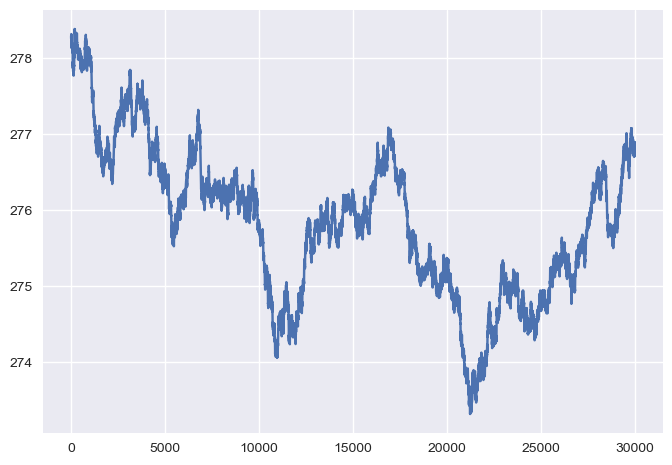

In [306]:
spread = y5 @ beta
plt.plot(spread)

In [307]:
import statsmodels.tsa.stattools as ts
cadf = ts.adfuller(spread)
print ('Augmented Dickey Fuller test statistic =',cadf[0])
print ('Augmented Dickey Fuller p-value =',cadf[1])
print ('Augmented Dickey Fuller 1%, 5% and 10% test statistics =',cadf[4])

Augmented Dickey Fuller test statistic = -2.503006317533874
Augmented Dickey Fuller p-value = 0.11474456774234809
Augmented Dickey Fuller 1%, 5% and 10% test statistics = {'1%': np.float64(-3.430568009855954), '5%': np.float64(-2.8616363544632057), '10%': np.float64(-2.566821286540422)}


In [308]:
spread.mean()

np.float64(275.81874327475197)

In [309]:
spread.std()

np.float64(1.0001791138274787)

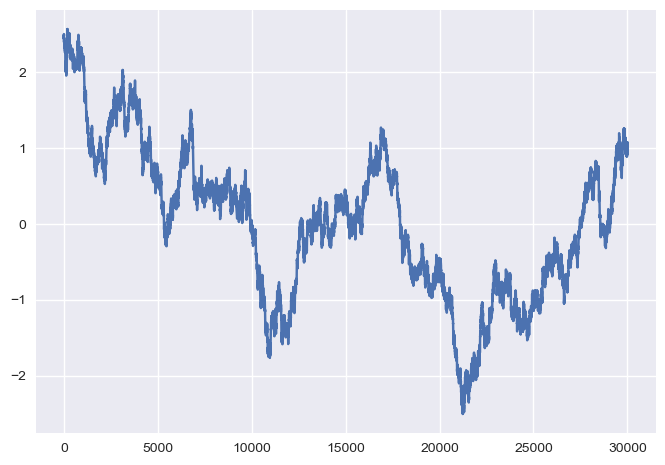

In [310]:
z_spread = (spread - spread.mean()) / spread.std()
plt.plot(z_spread)